# Import  packges required for nlp processing and analysis

In [161]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from rich.pretty import pprint

import spacy



### Data insights

In [162]:
plt.rcParams["figure.figsize"] = (12, 8)
default_color = "#00bfbf"


In [163]:
data = pd.read_csv(r'datasets\email_spam_dataset.csv')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   email_text  320 non-null    str  
 1   label       320 non-null    str  
dtypes: str(2)
memory usage: 5.1 KB


In [164]:
data.head()

,email_text,label
0,Here is the project update you asked for.,ham
1,Limited offer!!! Buy now and get 50% discount.,spam
2,Win cash prizes instantly by replying to this ...,spam
3,Urgent! Your account has been suspended. Verif...,spam
4,"Hi, please find the meeting agenda attached.",ham


Text(0.5, 1.0, 'Count Email Classification (Spam vs Ham)')

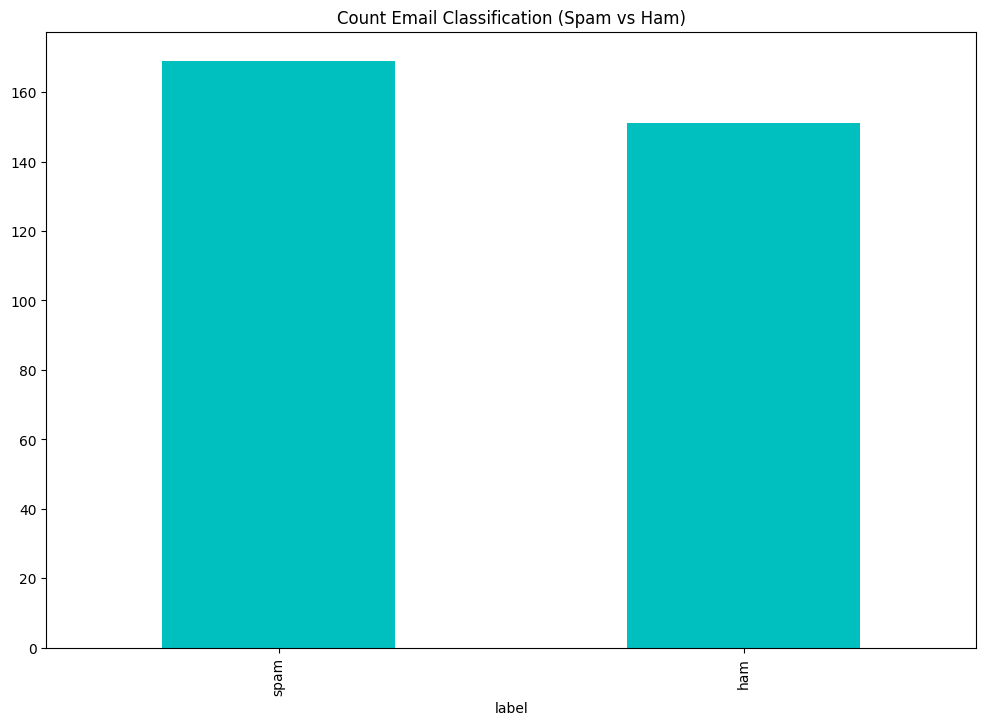

In [165]:
# comparing the number of spam to the number ham in the dataset
data["label"].value_counts().plot(kind="bar", color="#00bfbf")
plt.title("Count Email Classification (Spam vs Ham)")

In [166]:
pprint(data["label"][data["label"] == "spam"].value_counts())
pprint(data["label"][data["label"] == "ham"].value_counts())

label
spam    169
Name: count, dtype: int64

label
ham    151
Name: count, dtype: int64

# Text Tagging
Anaylsis text to find part of search and named entity that appear most in the dataset which will help the model understand the structure and meaning of sentences by identifying the roles of word and thier relationships

In [167]:
spam = data[data["label"] == "spam"]
ham = data[data["label"] == "ham"]

In [168]:
spam

,email_text,label
1,Limited offer!!! Buy now and get 50% discount.,spam
2,Win cash prizes instantly by replying to this ...,spam
3,Urgent! Your account has been suspended. Verif...,spam
8,You are selected for a free gift card. Act fast.,spam
10,Win cash prizes instantly by replying to this ...,spam
...,...,...
314,Win cash prizes instantly by replying to this ...,spam
316,You are selected for a free gift card. Act fast.,spam
317,Win cash prizes instantly by replying to this ...,spam
318,Limited offer!!! Buy now and get 50% discount.,spam


In [169]:
ham

,email_text,label
0,Here is the project update you asked for.,ham
4,"Hi, please find the meeting agenda attached.",ham
5,Here is the project update you asked for.,ham
6,Can we reschedule our meeting to tomorrow?,ham
7,Hope you are doing well. Let's catch up soon.,ham
...,...,...
306,Can we reschedule our meeting to tomorrow?,ham
307,Hope you are doing well. Let's catch up soon.,ham
309,"Hi, please find the meeting agenda attached.",ham
312,Here is the project update you asked for.,ham


In [170]:
# taking care duplicate in the colums
pprint(ham["email_text"].duplicated().any())
pprint(spam["email_text"].duplicated().any())

# droping duplicate emails
ham.drop_duplicates(subset="email_text", keep="first", inplace=True)
spam.drop_duplicates(subset="email_text", keep="first", inplace=True)

np.True_

np.True_

In [171]:
# after droping duplicates
pprint(ham["email_text"].duplicated().any())
pprint(spam["email_text"].duplicated().any())


np.False_

np.False_

In [172]:
nlp = spacy.load("en_core_web_sm")
spam_doc = list(nlp.pipe(spam["email_text"]))
ham_doc = list(nlp.pipe(ham["email_text"]))

In [173]:
pprint(spam_doc)
pprint(ham_doc)

[
│   Limited offer!!! Buy now and get 50% discount.,
│   Win cash prizes instantly by replying to this email.,
│   Urgent! Your account has been suspended. Verify immediately.,
│   You are selected for a free gift card. Act fast.,
│   Congratulations! You have won a free lottery. Click here to claim now.
]

[
│   Here is the project update you asked for.,
│   Hi, please find the meeting agenda attached.,
│   Can we reschedule our meeting to tomorrow?,
│   Hope you are doing well. Let's catch up soon.,
│   Thank you for your support. Let me know if you need anything.
]

In [174]:
def extract_tokens_tags(doc: spacy.tokens.doc.Doc):
    return [(token.text, token.pos_, token.ent_type_) for token in doc]

In [175]:
def create_token_df(doc):
    df = []
    columns = ["token", "pos_tags", "ner_tags"]

    for _, doc in enumerate(doc):
        tags = extract_tokens_tags(doc)
        tags = pd.DataFrame(tags)
        tags.columns = columns
        df.append(tags)
    return pd.concat(df)


In [176]:
spam_tags_df = create_token_df(spam_doc)
ham_tags_df = create_token_df(ham_doc)

### Analysising Part of Speech Tags

In [177]:
spam_tags_df.head(7)

,token,pos_tags,ner_tags
0,Limited,ADJ,
1,offer,NOUN,
2,!,PUNCT,
3,!,PUNCT,
4,!,PUNCT,
5,Buy,VERB,
6,now,ADV,


In [178]:
# pos token  count
spam_count_pos = spam_tags_df.groupby(["token", "pos_tags"]).size().reset_index(name="pos_count").sort_values(by="pos_count", ascending=False)
ham_count_pos = ham_tags_df.groupby(["token", "pos_tags"]).size().reset_index(name="pos_count").sort_values(by="pos_count", ascending=False)

In [179]:
spam_count_pos.head(5)

,token,pos_tags,pos_count
2,.,PUNCT,8
0,!,PUNCT,5
12,You,PRON,2
36,now,ADV,2
27,free,ADJ,2


In [180]:
ham_count_pos.head(5)

,token,pos_tags,pos_count
2,.,PUNCT,6
38,you,PRON,4
8,Let,VERB,2
23,meeting,NOUN,2
18,for,ADP,2


In [181]:
# cunct frequency of pos tags
spam_count_pos.groupby(["pos_tags"])["token"].count().sort_values(ascending=False)

pos_tags
NOUN     11
VERB     10
ADV       5
AUX       4
ADP       3
PROPN     2
ADJ       2
PRON      2
DET       2
PUNCT     2
CCONJ     1
PART      1
NUM       1
Name: token, dtype: int64

In [182]:
ham_count_pos.groupby(["pos_tags"])["token"].count().sort_values(ascending=False)

pos_tags
VERB     11
PRON      7
NOUN      6
ADP       3
ADV       3
AUX       3
PUNCT     3
INTJ      2
DET       1
SCONJ     1
Name: token, dtype: int64

[Text(0.5, 1.0, 'Most Common Part of Speech in Spam Email')]

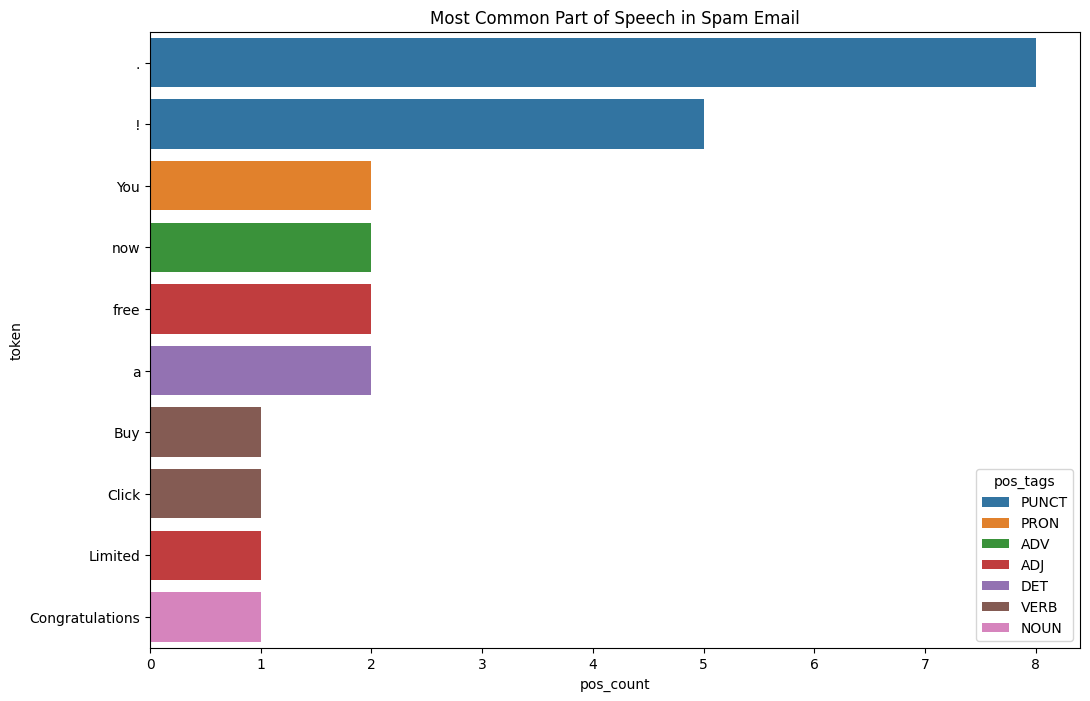

In [183]:
sns.barplot(
    x = "pos_count",
    y="token",
    hue="pos_tags",
    # palette=pos_palette,
    data = spam_count_pos[:10],
    dodge=False
).set(title="Most Common Part of Speech in Spam Email")

[Text(0.5, 1.0, 'Most Common Part of Speech in Ham Email')]

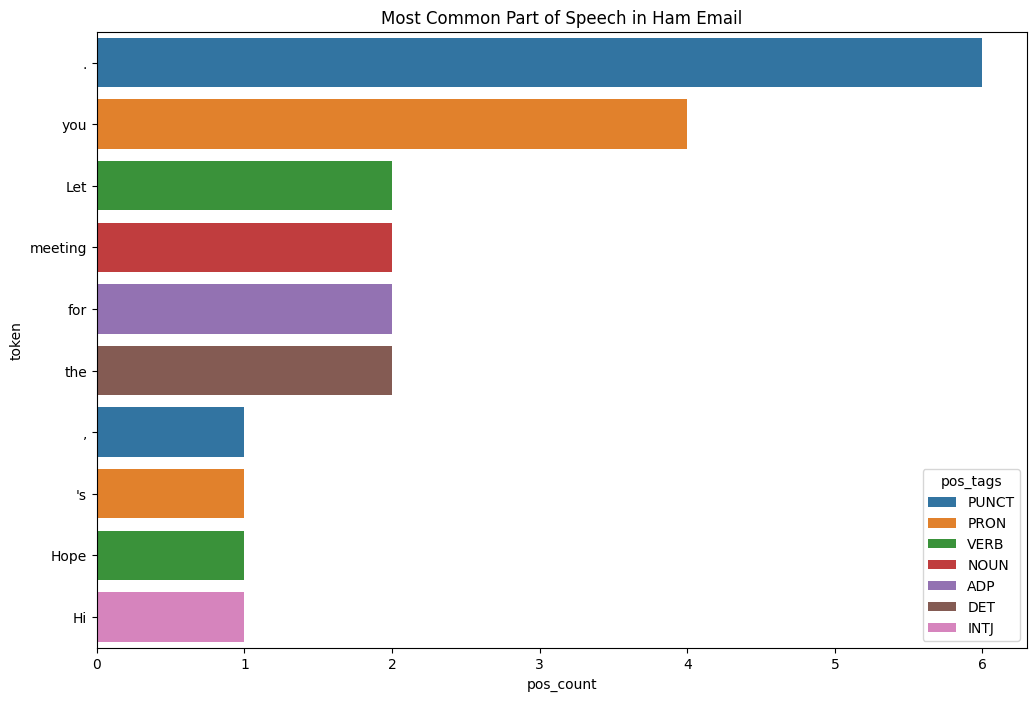

In [184]:
sns.barplot(
    x = "pos_count",
    y="token",
    hue="pos_tags",
    # palette=pos_palette,
    data = ham_count_pos[:10],
    dodge=False
).set(title="Most Common Part of Speech in Ham Email")

### Analysising Named Entity Tags

In [185]:
ham_tags_df["ner_tags"].values

<StringArray>
[    '',     '',     '',     '',     '',     '',     '',     '',     '',
     '',     '',     '',     '',     '',     '',     '',     '',     '',
     '',     '',     '',     '',     '',     '', 'DATE',     '',     '',
     '',     '',     '',     '',     '',     '',     '',     '',     '',
     '',     '',     '',     '',     '',     '',     '',     '',     '',
     '',     '',     '',     '',     '',     '',     '']
Length: 52, dtype: str

In [186]:
# ner_tags token  count
spam_count_ner = spam_tags_df.groupby(["token", "ner_tags"]).size().reset_index(name="ner_count").sort_values(by="ner_count", ascending=False)
ham_count_ner = ham_tags_df.groupby(["token", "ner_tags"]).size().reset_index(name="ner_count").sort_values(by="ner_count", ascending=False)

In [187]:
spam_count_ner.head(5)

,token,ner_tags,ner_count
2,.,,8
0,!,,5
12,You,,2
27,free,,2
14,a,,2


In [188]:
ham_count_ner.head(5)

,token,ner_tags,ner_count
2,.,,6
38,you,,4
8,Let,,2
23,meeting,,2
18,for,,2


In [189]:
# count frequency of pos tags
spam_count_ner.groupby(["ner_tags"])["token"].count().sort_values(ascending=False)

ner_tags
           43
PERCENT     2
Name: token, dtype: int64

In [190]:
ham_count_ner.groupby(["ner_tags"])["token"].count().sort_values(ascending=False)

ner_tags
        39
DATE     1
Name: token, dtype: int64

`Note:` from analysis it can be observed that the named entity from the data is very low - nothing

# Text Preprocessing

# Sentiment Analysis

# LDA

# TF-IDF & LSA

# Predict Spam or Ham